In [2]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [12]:
library(corrr)

In [3]:
df <- read.csv("data_abs.xlsx - data_abs.xls.csv")

In [4]:
df <- df %>% select(-1)

In [5]:
glimpse(df)

Rows: 96
Columns: 14
$ Department <chr> "Ain", "Aisne", "Allier", "Alpes-de-Haute-Provence", "Haute…
$ Code       <chr> "1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "1…
$ HLM        <dbl> 14.4, 16.0, 10.8, 7.6, 11.3, 8.8, 7.5, 18.0, 4.5, 19.6, 8.2…
$ Salairemoy <dbl> 13.58, 12.52, 12.10, 12.73, 12.04, 14.22, 12.65, 12.60, 12.…
$ Ouvrier    <dbl> 27.4, 28.6, 24.7, 19.6, 18.9, 15.5, 23.4, 29.2, 20.6, 26.6,…
$ Employe    <dbl> 26.3, 30.5, 32.2, 30.0, 32.4, 31.1, 28.4, 29.3, 31.4, 29.0,…
$ PI         <dbl> 25.3, 22.6, 22.3, 25.7, 26.6, 25.2, 24.0, 22.7, 24.8, 23.7,…
$ Cadres     <dbl> 11.8, 9.6, 9.2, 10.7, 9.4, 17.6, 10.5, 9.7, 9.6, 10.6, 10.5…
$ Artisant   <dbl> 7.5, 6.1, 7.4, 10.4, 9.8, 10.2, 10.1, 6.2, 9.5, 6.3, 10.1, …
$ Agri       <dbl> 1.7, 2.6, 4.3, 3.6, 2.9, 0.4, 3.6, 3.0, 4.1, 3.8, 4.0, 8.7,…
$ TxPauv     <dbl> 10.8, 18.7, 15.4, 17.0, 14.5, 16.0, 14.7, 19.4, 18.2, 15.6,…
$ NonDiplome <dbl> 29.4, 39.9, 36.4, 31.3, 28.4, 31.6, 33.8, 39.1, 33.6, 38.1,…
$ txcho      <dbl> 

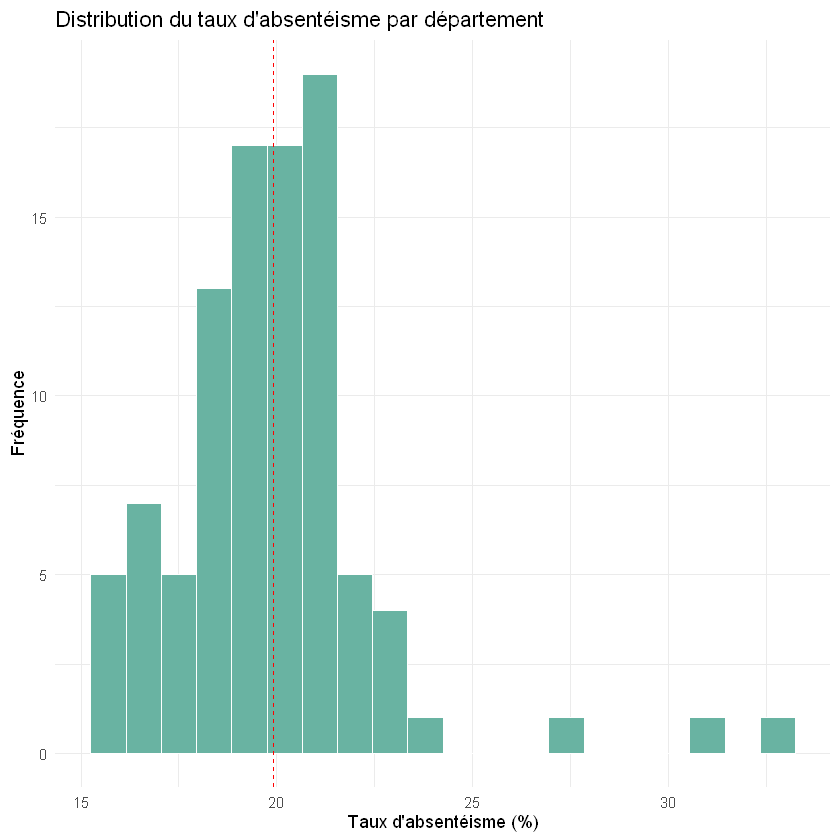

In [6]:
ggplot(df, aes(x = txabs)) +
  geom_histogram(bins = 20, fill = "#69b3a2", color = "white") +
  geom_vline(aes(xintercept = mean(txabs)), color = "red", linetype = "dashed") +
  labs(title = "Distribution du taux d'absentéisme par département",
       x = "Taux d'absentéisme (%)", y = "Fréquence") +
  theme_minimal()

In [7]:
df_csp <- df %>% 
  select(Ouvrier, Cadres) %>% 
  pivot_longer(cols = everything(), names_to = "CSP", values_to = "Pourcentage")

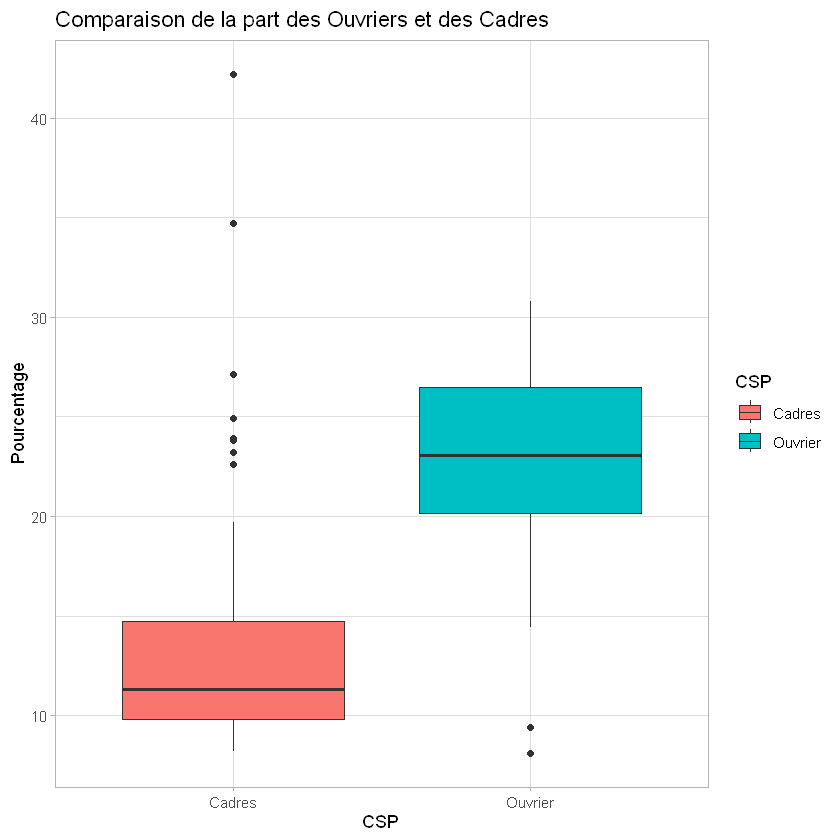

In [8]:
ggplot(df_csp, aes(x = CSP, y = Pourcentage, fill = CSP)) +
  geom_boxplot() +
  labs(title = "Comparaison de la part des Ouvriers et des Cadres") +
  theme_light()

`geom_smooth()` using formula = 'y ~ x'


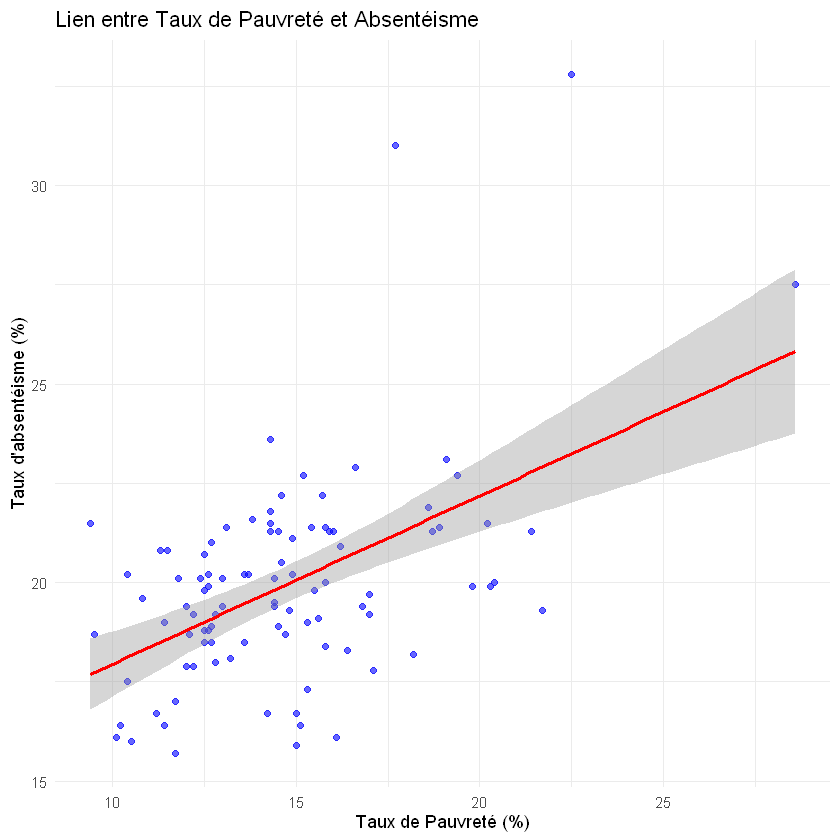

In [9]:
ggplot(df, aes(x = TxPauv, y = txabs)) +
  geom_point(alpha = 0.6, color = "blue") +
  geom_smooth(method = "lm", color = "red") +
  labs(title = "Lien entre Taux de Pauvreté et Absentéisme",
       x = "Taux de Pauvreté (%)", y = "Taux d'absentéisme (%)") +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


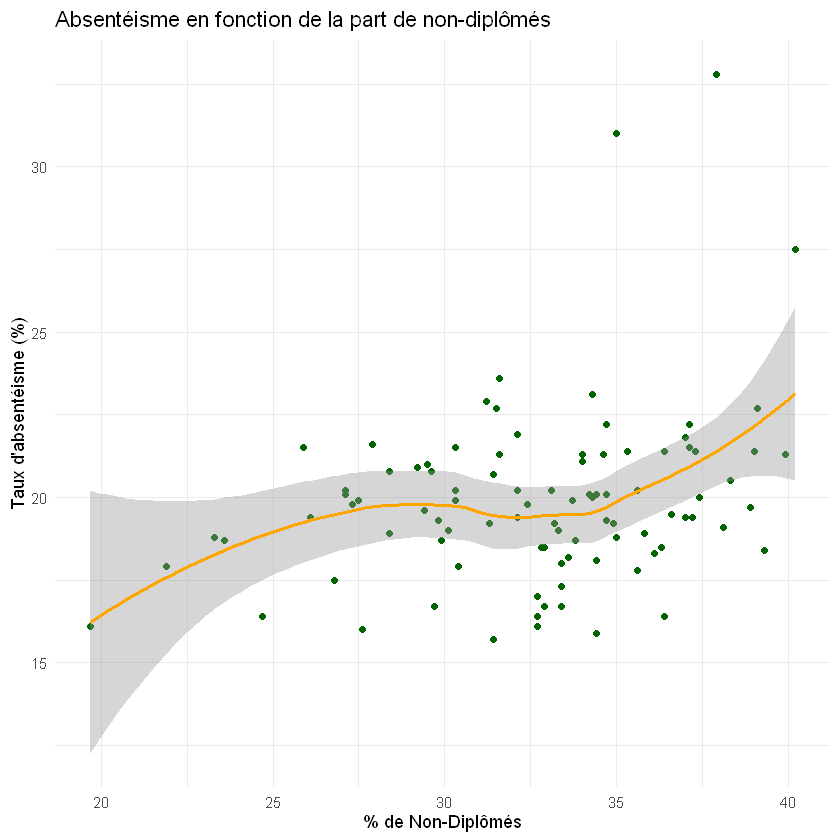

In [10]:
ggplot(df, aes(x = NonDiplome, y = txabs)) +
  geom_point(color = "darkgreen") +
  geom_smooth(method = "loess", color = "orange") +
  labs(title = "Absentéisme en fonction de la part de non-diplômés",
       x = "% de Non-Diplômés", y = "Taux d'absentéisme (%)") +
  theme_minimal()

In [13]:
df %>%
  select(where(is.numeric)) %>%
  correlate() %>%
  rearrange() %>%
  shave() %>%
  fashion()

Correlation computed with
• Method: 'pearson'
• Missing treated using: 'pairwise.complete.obs'


term,Cadres,Salairemoy,PI,HLM,txabs,txcho,TxPauv,Artisant,Ouvrier,Employe,Agri,NonDiplome
<noquote>,<noquote>,<noquote>,<noquote>,<noquote>,<noquote>,<noquote>,<noquote>,<noquote>,<noquote>,<noquote>,<noquote>,<noquote>
Cadres,,,,,,,,,,,,
Salairemoy,.92,,,,,,,,,,,
PI,.61,.53,,,,,,,,,,
HLM,.54,.53,.43,,,,,,,,,
txabs,.01,-.04,.04,.28,,,,,,,,
txcho,-.12,-.20,.06,.07,.35,,,,,,,
TxPauv,-.06,-.18,-.15,.11,.51,.75,,,,,,
Artisant,-.49,-.47,-.37,-.74,.03,.21,.27,,,,,
Ouvrier,-.75,-.65,-.54,-.14,-.10,-.06,-.20,-.08,,,,
